<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_7_(Exercise_7_2)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Imports and Data

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from skimage.metrics import structural_similarity as ssim_fn
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.CIFAR10(root='./data', train=True,
                              download=True, transform=transform)
train_data = Subset(train_data, range(10000))
train_loader = DataLoader(train_data, batch_size=64,
                          shuffle=True, num_workers=0)

test_data = datasets.CIFAR10(root='./data', train=False,
                             download=True, transform=transform)
test_data = Subset(test_data, range(500))
test_loader = DataLoader(test_data, batch_size=64,
                         shuffle=False, num_workers=0)

Using: cpu


100%|██████████| 170M/170M [03:09<00:00, 901kB/s]


In [3]:
# Install and Set Up LPIPS

!pip install lpips -q
import lpips

lpips_fn = lpips.LPIPS(net='alex').to(device)
for p in lpips_fn.parameters():
    p.requires_grad_(False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.8 MB/s eta 0:00:00
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 145MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [4]:
# Autoencoder Architecture

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_enc = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 128 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.fc_enc(self.encoder(x))
        out = self.decoder(self.fc_dec(z))
        return out

In [5]:
# Frozen VGG-16 Perceptual Feature Extractor

class VGGPerceptual(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
        self.slice1 = nn.Sequential(*list(vgg.children())[:9])
        self.slice2 = nn.Sequential(*list(vgg.children())[9:16])

        for p in self.parameters():
            p.requires_grad_(False)
        self.eval()

        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        x = (x - self.mean) / self.std
        f1 = self.slice1(x)
        f2 = self.slice2(f1)
        return f1, f2


vgg_extractor = VGGPerceptual().to(device)


def perceptual_loss(x, x_hat, vgg_extractor):
    f1_x,  f2_x  = vgg_extractor(x)
    f1_xh, f2_xh = vgg_extractor(x_hat)
    loss_relu2_2 = F.l1_loss(f1_x, f1_xh)
    loss_relu3_3 = F.l1_loss(f2_x, f2_xh)
    return loss_relu2_2 + loss_relu3_3

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:11<00:00, 48.6MB/s]


In [6]:
# Train Model A (L1 Only) and Model B (L1 + Perceptual)

def train_autoencoder(use_perceptual, epochs=12, lam_percep=0.1):
    model     = Autoencoder(latent_dim=128).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        total_loss = 0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)

            recon = model(imgs)
            l1_loss = F.l1_loss(recon, imgs)

            if use_perceptual:
                p_loss = perceptual_loss(imgs, recon, vgg_extractor)
                loss = l1_loss + lam_percep * p_loss
            else:
                loss = l1_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"[{'L1+percep' if use_perceptual else 'L1 only'}] "
              f"Epoch {epoch+1}/{epochs} — Loss: {total_loss/len(train_loader):.4f}")

    return model


print("Training Model A — L1 pixel loss only...")
model_l1 = train_autoencoder(use_perceptual=False, epochs=12)

print("\nTraining Model B — L1 + perceptual loss...")
model_percep = train_autoencoder(use_perceptual=True, epochs=12)

Training Model A — L1 pixel loss only...
[L1 only] Epoch 1/12 — Loss: 0.1449
[L1 only] Epoch 2/12 — Loss: 0.0992
[L1 only] Epoch 3/12 — Loss: 0.0858
[L1 only] Epoch 4/12 — Loss: 0.0793
[L1 only] Epoch 5/12 — Loss: 0.0744
[L1 only] Epoch 6/12 — Loss: 0.0703
[L1 only] Epoch 7/12 — Loss: 0.0674
[L1 only] Epoch 8/12 — Loss: 0.0653
[L1 only] Epoch 9/12 — Loss: 0.0629
[L1 only] Epoch 10/12 — Loss: 0.0617
[L1 only] Epoch 11/12 — Loss: 0.0609
[L1 only] Epoch 12/12 — Loss: 0.0593

Training Model B — L1 + perceptual loss...
[L1+percep] Epoch 1/12 — Loss: 0.5315
[L1+percep] Epoch 2/12 — Loss: 0.4587
[L1+percep] Epoch 3/12 — Loss: 0.4274
[L1+percep] Epoch 4/12 — Loss: 0.4054
[L1+percep] Epoch 5/12 — Loss: 0.3928
[L1+percep] Epoch 6/12 — Loss: 0.3832
[L1+percep] Epoch 7/12 — Loss: 0.3743
[L1+percep] Epoch 8/12 — Loss: 0.3667
[L1+percep] Epoch 9/12 — Loss: 0.3600
[L1+percep] Epoch 10/12 — Loss: 0.3536
[L1+percep] Epoch 11/12 — Loss: 0.3483
[L1+percep] Epoch 12/12 — Loss: 0.3438


In [7]:
# Evaluation Function and Sample Images (needed later)

def evaluate_model(model, loader, lpips_fn):
    model.eval()
    ssim_scores, lpips_scores = [], []

    with torch.no_grad():
        for imgs, _ in loader:
            imgs  = imgs.to(device)
            recon = model(imgs)

            lp = lpips_fn(imgs * 2 - 1, recon * 2 - 1)
            lpips_scores.extend(lp.squeeze().cpu().numpy().tolist())

            for i in range(imgs.size(0)):
                orig = imgs[i].permute(1, 2, 0).cpu().numpy()
                rec  = recon[i].permute(1, 2, 0).cpu().numpy()
                s = ssim_fn(orig, rec, data_range=1.0, channel_axis=2)
                ssim_scores.append(s)

    return np.mean(ssim_scores), np.mean(lpips_scores)


ssim_l1, lpips_l1         = evaluate_model(model_l1, test_loader, lpips_fn)
ssim_percep, lpips_percep = evaluate_model(model_percep, test_loader, lpips_fn)

print(f"{'Model':<15} {'SSIM':>10} {'LPIPS':>10}")
print("-" * 36)
print(f"{'L1 only':<15} {ssim_l1:>10.4f} {lpips_l1:>10.4f}")
print(f"{'L1+percep':<15} {ssim_percep:>10.4f} {lpips_percep:>10.4f}")

# Fixed sample for grid comparisons later
torch.manual_seed(7)
sample_imgs, _ = next(iter(test_loader))
sample_imgs    = sample_imgs[:10].to(device)

Model                 SSIM      LPIPS
------------------------------------
L1 only             0.7094     0.1739
L1+percep           0.6718     0.1112


In [8]:
 # Patch Discriminator

class PatchDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1),    # 32 -> 16
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # 16 -> 8
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, stride=2, padding=1), # 8 -> 4
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 1, 3, stride=1, padding=1)    # stays 4x4 — NO flattening
        )

    def forward(self, x):
        return self.net(x)   # (B, 1, 4, 4) — a spatial grid, not a scalar


# Sanity check: confirm the output is genuinely spatial
disc_test = PatchDiscriminator().to(device)
test_out  = disc_test(torch.randn(2, 3, 32, 32).to(device))
print(f"Discriminator output shape: {test_out.shape}  (should be (2, 1, 4, 4))")

Discriminator output shape: torch.Size([2, 1, 4, 4])  (should be (2, 1, 4, 4))


In [9]:
 # Hinge Losses

def discriminator_hinge_loss(d_real, d_fake):
    loss_real = F.relu(1.0 - d_real).mean()
    loss_fake = F.relu(1.0 + d_fake).mean()
    return loss_real + loss_fake


def generator_adversarial_loss(d_fake):
    return -d_fake.mean()

In [10]:
# Train The Third Model: L1 + Perceptual + Adversarial

def train_autoencoder_adversarial(epochs=12, lam_percep=0.1, lam_adv=0.05,
                                   disc_start_epoch=3):
    model     = Autoencoder(latent_dim=128).to(device)
    disc      = PatchDiscriminator().to(device)

    opt_g = optim.Adam(model.parameters(), lr=1e-3, betas=(0.5, 0.9))
    opt_d = optim.Adam(disc.parameters(),  lr=1e-4, betas=(0.5, 0.9))

    for epoch in range(epochs):
        use_adv = epoch >= disc_start_epoch
        total_g_loss, total_d_loss = 0, 0

        for imgs, _ in train_loader:
            imgs = imgs.to(device)

            # ---- Generator (autoencoder) step ----
            recon = model(imgs)
            l1_loss = F.l1_loss(recon, imgs)
            p_loss  = perceptual_loss(imgs, recon, vgg_extractor)

            g_loss = l1_loss + lam_percep * p_loss

            if use_adv:
                d_fake_for_g = disc(recon)
                g_loss = g_loss + lam_adv * generator_adversarial_loss(d_fake_for_g)

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()
            total_g_loss += g_loss.item()

            # ---- Discriminator step ----
            if use_adv:
                with torch.no_grad():
                    recon_detached = model(imgs)

                d_real = disc(imgs)
                d_fake = disc(recon_detached)
                d_loss = discriminator_hinge_loss(d_real, d_fake)

                opt_d.zero_grad()
                d_loss.backward()
                opt_d.step()
                total_d_loss += d_loss.item()

        print(f"Epoch {epoch+1}/{epochs} | G: {total_g_loss/len(train_loader):.4f} | "
              f"D: {total_d_loss/len(train_loader):.4f} | adv {'ON' if use_adv else 'off (warmup)'}")

    return model, disc


print("Training Model C — L1 + perceptual + adversarial...")
model_adv, discriminator = train_autoencoder_adversarial(epochs=12)

Training Model C — L1 + perceptual + adversarial...
Epoch 1/12 | G: 0.5261 | D: 0.0000 | adv off (warmup)
Epoch 2/12 | G: 0.4620 | D: 0.0000 | adv off (warmup)
Epoch 3/12 | G: 0.4357 | D: 0.0000 | adv off (warmup)
Epoch 4/12 | G: 0.4385 | D: 1.9056 | adv ON
Epoch 5/12 | G: 0.4403 | D: 1.9168 | adv ON
Epoch 6/12 | G: 0.4355 | D: 1.9177 | adv ON
Epoch 7/12 | G: 0.4267 | D: 1.9161 | adv ON
Epoch 8/12 | G: 0.4200 | D: 1.9250 | adv ON
Epoch 9/12 | G: 0.4128 | D: 1.9208 | adv ON
Epoch 10/12 | G: 0.4058 | D: 1.9192 | adv ON
Epoch 11/12 | G: 0.3990 | D: 1.9265 | adv ON
Epoch 12/12 | G: 0.3938 | D: 1.9421 | adv ON


In [11]:
# Evaluate All Three Models

ssim_adv, lpips_adv = evaluate_model(model_adv, test_loader, lpips_fn)

print(f"{'Model':<20} {'SSIM':>10} {'LPIPS':>10}")
print("-" * 42)
print(f"{'L1 only':<20} {ssim_l1:>10.4f} {lpips_l1:>10.4f}")
print(f"{'L1+percep':<20} {ssim_percep:>10.4f} {lpips_percep:>10.4f}")
print(f"{'L1+percep+adv':<20} {ssim_adv:>10.4f} {lpips_adv:>10.4f}")

Model                      SSIM      LPIPS
------------------------------------------
L1 only                  0.7094     0.1739
L1+percep                0.6718     0.1112
L1+percep+adv            0.6007     0.0560


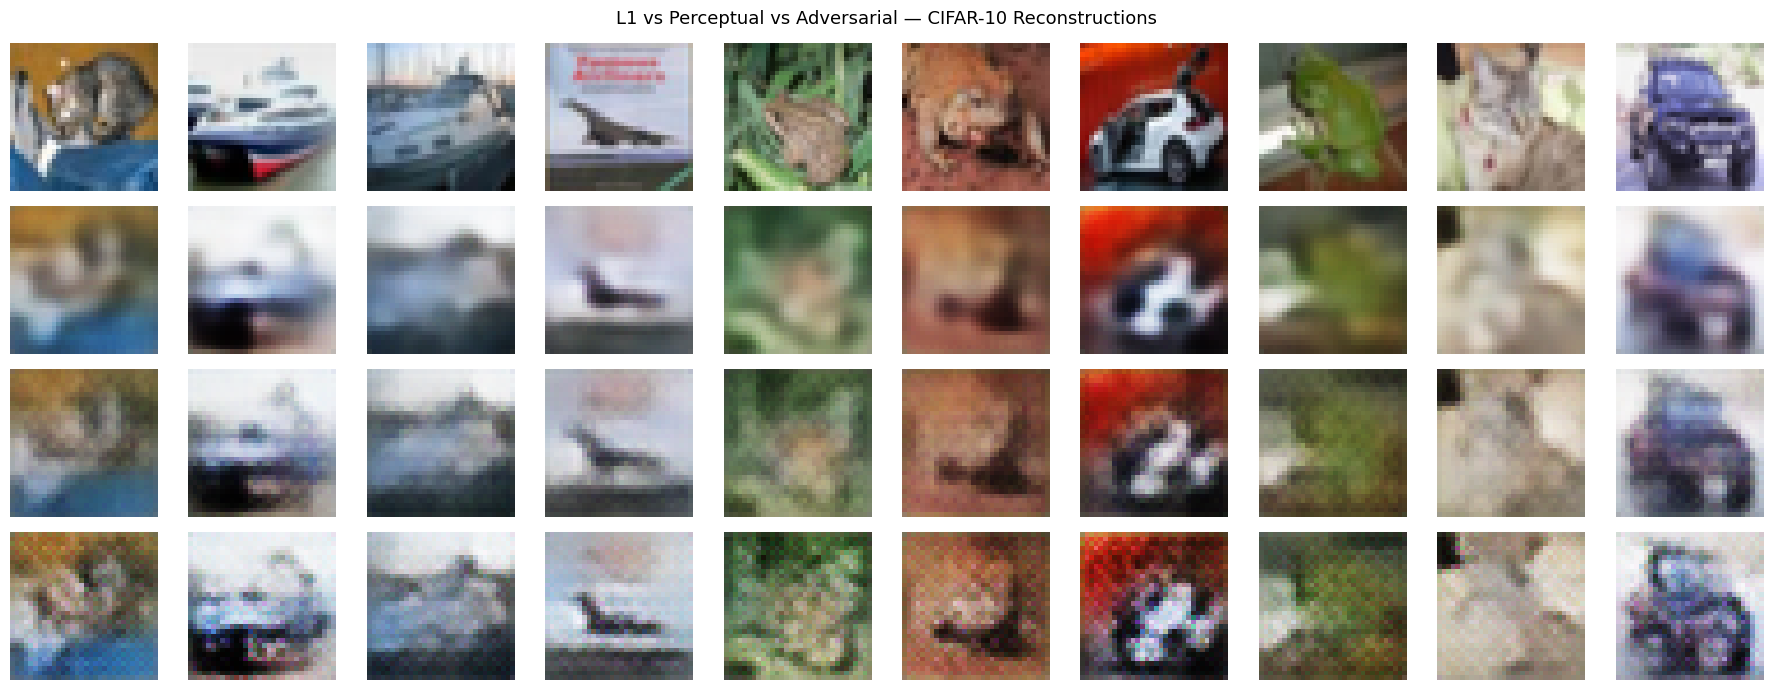

In [12]:
# Qualitative Grid: Original + All Three Models

model_l1.eval(); model_percep.eval(); model_adv.eval()
with torch.no_grad():
    recon_l1_     = model_l1(sample_imgs)
    recon_percep_ = model_percep(sample_imgs)
    recon_adv_    = model_adv(sample_imgs)

fig, axes = plt.subplots(4, 10, figsize=(18, 7))
row_labels = ['Original', 'L1 only', 'L1+percep', 'L1+percep+adv']
rows_data  = [sample_imgs, recon_l1_, recon_percep_, recon_adv_]

for row in range(4):
    for col in range(10):
        axes[row, col].imshow(rows_data[row][col].permute(1, 2, 0).cpu().numpy())
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(row_labels[row], fontsize=10)

plt.suptitle('L1 vs Perceptual vs Adversarial — CIFAR-10 Reconstructions', fontsize=13)
plt.tight_layout()
plt.savefig('adversarial_7_2.png', dpi=150)
plt.show()

# Interpretation And Observation

#### Adding adversarial loss continued the perception-distortion tradeoff observed in Exercise 7.1, dropping SSIM further from 0.6718 to 0.6007 while LPIPS improved substantially from 0.1112 to 0.0560, the largest single improvement across the three models — consistent with adversarial loss exerting the strongest pressure toward photorealistic, in-distribution output among the three loss configurations tested. However, the qualitative grid does not show the checkerboard mesh artifact from the L1+perceptual row meaningfully disappearing in the L1+perceptual+adversarial row, which contradicts the hypothesis floated at the end of 7.1 that a patch discriminator would specifically learn to penalize this pattern as an easy giveaway of fakeness. Checking the literature on this specific point rather than assuming it, transposed convolution checkerboard artifacts are documented as a network-inherent property of the upsampling operation's geometry, arising from uneven kernel overlap at initialization, and have been explicitly observed to persist largely unaffected by training, including adversarial training in GAN settings specifically. This means the artifact is not a loss-function problem that more or different training signal can reliably fix, but an architecture problem requiring an architectural fix — replacing the transposed convolutions with a resize-then-convolve upsampling scheme, as Odena et al. themselves recommend. The practical implication for LDAE is significant: its real AutoencoderKL achieves SSIM of 0.962 on brain MRI while using a perceptual-plus-adversarial training recipe, which means its actual upsampling architecture must avoid this failure mode by design rather than relying on the adversarial loss term to suppress it after the fact, exactly as this toy experiment suggests is necessary.